In [22]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [23]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import scipy
from PIL import Image
import pandas as pd
import torch
import torch.nn as nn
from computer_vision.utils import load_happy_dataset

%matplotlib inline
np.random.seed(1)

In [24]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_happy_dataset()

X_train = X_train_orig/255.
X_test = X_test_orig/255.

# Reshape
Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)


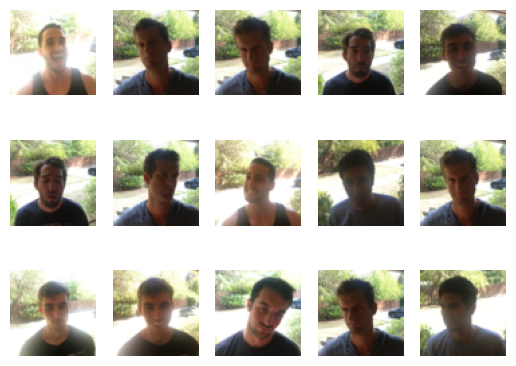

In [25]:
m = 15
random_indices = np.random.choice(X_train.shape[0], m, replace=False)
for i in range(m):
    index = random_indices[i]
    plt.subplot(3, 5, i+1)
    plt.imshow(X_train_orig[index])
    plt.axis('off')
plt.show()

In [26]:
def happyModel():
    """
    Implements the forward propagation for the binary classification model:
    ZEROPAD2D -> CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> FLATTEN -> DENSE
    """
    model = nn.Sequential(
        nn.ZeroPad2d(3),
        nn.Conv2d(in_channels=3, out_channels=8, kernel_size=7, stride=1),
        nn.BatchNorm2d(8),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(in_features=16*15*15, out_features=1),
        nn.Sigmoid()
    )
    
    return model

In [27]:
happy_model = happyModel()
# Print a summary for each layer
for layer in happy_model:
    print(layer)

ZeroPad2d((3, 3, 3, 3))
Conv2d(3, 8, kernel_size=(7, 7), stride=(1, 1))
BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
ReLU()
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
ReLU()
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
Flatten(start_dim=1, end_dim=-1)
Linear(in_features=3600, out_features=1, bias=True)
Sigmoid()


In [28]:
# compilar el modelo loss binary_crossentropy, optimizer adam, metrics accuracy
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(happy_model.parameters(), lr=0.00001)

# Convertir los datos a tensores de PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)  # Cambiar a formato (N, C, H, W)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1)  # Cambiar a formato (N, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)  # Cambiar a formato (N, C, H, W)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1)  # Cambiar a formato (N, 1)

# Entrenar el modelo durante 10 épocas
list_loss = []
list_train_acc = []
list_test_acc = []
num_epochs = 100
for epoch in range(num_epochs):
    happy_model.train()
    optimizer.zero_grad()
    
    # Forward pass
    outputs = happy_model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    # Evaluar el modelo en el conjunto de entrenamiento
    happy_model.eval()
    with torch.no_grad():
        train_outputs = happy_model(X_train_tensor)
        train_predictions = (train_outputs > 0.5).float()
        train_accuracy = (train_predictions == Y_train_tensor).float().mean()

        test_outputs = happy_model(X_test_tensor)
        test_predictions = (test_outputs > 0.5).float()
        test_accuracy = (test_predictions == Y_test_tensor).float().mean()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy.item():.4f}, Test Accuracy: {test_accuracy.item():.4f}')
    list_loss.append(loss.item())
    list_train_acc.append(train_accuracy.item())
    list_test_acc.append(test_accuracy.item())


Epoch [1/100], Loss: 0.7514, Train Accuracy: 0.4883, Test Accuracy: 0.3800
Epoch [2/100], Loss: 0.7483, Train Accuracy: 0.5033, Test Accuracy: 0.4133
Epoch [3/100], Loss: 0.7453, Train Accuracy: 0.4933, Test Accuracy: 0.4000
Epoch [4/100], Loss: 0.7425, Train Accuracy: 0.5033, Test Accuracy: 0.4200
Epoch [5/100], Loss: 0.7398, Train Accuracy: 0.5067, Test Accuracy: 0.4400
Epoch [6/100], Loss: 0.7372, Train Accuracy: 0.5017, Test Accuracy: 0.4400
Epoch [7/100], Loss: 0.7348, Train Accuracy: 0.5000, Test Accuracy: 0.4400
Epoch [8/100], Loss: 0.7325, Train Accuracy: 0.5000, Test Accuracy: 0.4400
Epoch [9/100], Loss: 0.7303, Train Accuracy: 0.5017, Test Accuracy: 0.4400
Epoch [10/100], Loss: 0.7283, Train Accuracy: 0.5017, Test Accuracy: 0.4400
Epoch [11/100], Loss: 0.7264, Train Accuracy: 0.5000, Test Accuracy: 0.4333
Epoch [12/100], Loss: 0.7246, Train Accuracy: 0.5000, Test Accuracy: 0.4333
Epoch [13/100], Loss: 0.7229, Train Accuracy: 0.4983, Test Accuracy: 0.4267
Epoch [14/100], Loss:

In [29]:
# evaluar el modelo para X_test y Y_test, imprimir la loss y accuracy
happy_model.eval()
with torch.no_grad():
    test_outputs = happy_model(X_test_tensor)
    test_loss = criterion(test_outputs, Y_test_tensor)
    test_predictions = (test_outputs > 0.5).float()
    test_accuracy = (test_predictions == Y_test_tensor).float().mean()

print(f'Test Loss: {test_loss.item():.4f}, Test Accuracy: {test_accuracy.item():.4f}')

Test Loss: 0.6672, Test Accuracy: 0.6133


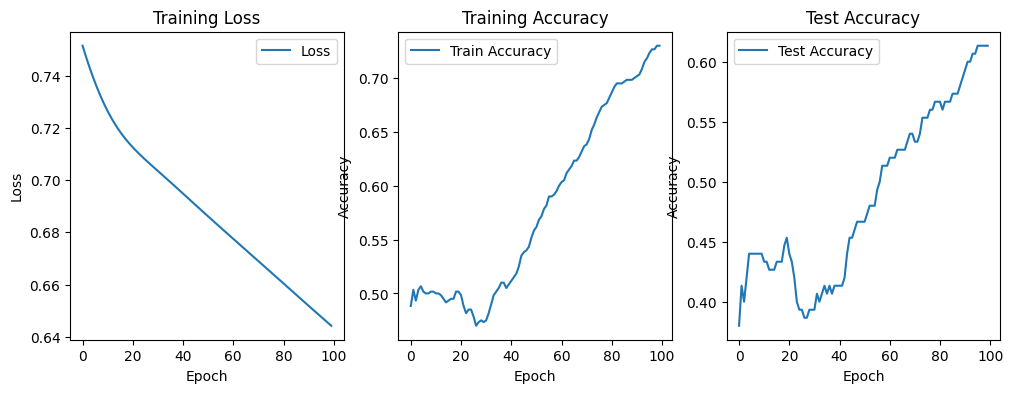

In [30]:
# graficar la perdida y el accuracy durante el entrenamiento que estan en list_loss, list_train_acc, list_test_acc
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(list_loss, label='Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(list_train_acc, label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(list_test_acc, label='Test Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()